## Libraries and imports

In [3]:
# Libraries
import sys
sys.path.append('..')
from feature_selection import data_feature_selection, split_data, split_data_3way, data_feature_selection_3way


import numpy as np
from datetime import datetime
import pandas as pd
import requests
import time
from numpy._core.defchararray import zfill
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import classification_report, confusion_matrix, recall_score, f1_score
from sklearn.utils.class_weight import compute_class_weight
import os
import gc
import tensorflow as tf
from os import scandir, mkdir
import xgboost as xgb
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve, average_precision_score, precision_score, recall_score, f1_score, confusion_matrix
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, Conv1D, BatchNormalization, Activation, Add, GlobalAveragePooling1D, GRU
from tensorflow.keras.callbacks import EarlyStopping
import itertools

#import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
# Get the dataset
df_ml = pd.read_csv("../../data/processed/DatasetMaster.csv")
df_ml.columns


Index(['time', 'temperature_2m', 'precipitation', 'relative_humidity_2m',
       'soil_moisture_0_to_7cm', 'soil_moisture_7_to_28cm',
       'soil_moisture_28_to_100cm', 'runoff', 'et0_fao_evapotranspiration',
       'wind_speed_10m', 'wind_gusts_10m', 'alcaldia', 'tema_solicitud',
       'severidad', 'incident', 'mes', 'dia_semana', 'hora_del_dia',
       'es_fin_de_semana', 'precipitation_sum_3h',
       'soil_moisture_0_to_7cm_mean_3h', 'soil_moisture_7_to_28cm_mean_3h',
       'relative_humidity_2m_mean_3h', 'precipitation_sum_6h',
       'soil_moisture_0_to_7cm_mean_6h', 'soil_moisture_7_to_28cm_mean_6h',
       'relative_humidity_2m_mean_6h', 'precipitation_sum_12h',
       'soil_moisture_0_to_7cm_mean_12h', 'soil_moisture_7_to_28cm_mean_12h',
       'relative_humidity_2m_mean_12h', 'precipitation_sum_24h',
       'soil_moisture_0_to_7cm_mean_24h', 'soil_moisture_7_to_28cm_mean_24h',
       'relative_humidity_2m_mean_24h'],
      dtype='object')

In [5]:
# Split data function
X_train, X_test, y_train, y_test = split_data(df_ml)

In [6]:
# Feature selection
X_train, X_test = data_feature_selection(X_train, X_test)

Original Feature Count: 48
Cleaned Feature Count:  37


Use StandardScaler to normalize the values

In [7]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Create sequences for temporal models. We use `window_size=24` because the data is hourly.

In [8]:
def create_sequences(X, y, window_size):
    X_seq = []
    y_seq = []

    for i in range(window_size, len(X)):
        X_seq.append(X[i-window_size:i])
        y_seq.append(y.iloc[i])

    return np.array(X_seq), np.array(y_seq)

In [9]:
window_size = 24
X_train_lstm, y_train_lstm = create_sequences(X_train_scaled, y_train, window_size)
X_test_lstm, y_test_lstm = create_sequences(X_test_scaled, y_test, window_size)

print(X_train_lstm.shape)
print(y_train_lstm.shape)

(854287, 24, 37)
(854287,)


We need to calculate class weights in order to train the model using balanced weights, compensating for the class imbalance between flood and non-flood events.

In [10]:
classes = np.unique(y_train_lstm)

weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=y_train_lstm
)

class_weights = dict(zip(classes, weights))

print(class_weights)

{np.int64(0): np.float64(0.5675247095900713), np.int64(1): np.float64(4.202348392428476)}


## Model creation

In [11]:
# Build LSTM model architecture
def build_lstm_model(window_size, n_features, lstm_units, dense_units, dropout_rate):

    model = Sequential([

        # LSTM layer for learning temporal dependencies
        LSTM(lstm_units, input_shape=(window_size, n_features)),

        # Dropout regularization to reduce overfitting
        Dropout(dropout_rate),

        # Dense layer for higher-level feature learning
        Dense(dense_units, activation="relu"),

        # Additional dropout regularization
        Dropout(dropout_rate / 2),

        # Final sigmoid layer for binary classification
        Dense(1, activation="sigmoid")
    ])

    # Configure optimizer, loss function, and evaluation metric
    model.compile(
        optimizer="adam",
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model

In [12]:
# Initialize LSTM model
# Number of features (variables) per timestep
n_features = X_train_lstm.shape[2]

# Build LSTM model with selected hyperparameters
lstm_model = build_lstm_model(
    window_size=window_size,
    n_features=n_features,
    lstm_units=64,      # Number of LSTM memory units
    dense_units=32,     # Number of neurons in dense layer
    dropout_rate=0.3    # Regularization strength
)

# Display model architecture summary
lstm_model.summary()

c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        26,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,225 (110.25 KB)

 Trainable params: 28,225 (110.25 KB)

 Non-trainable params: 0 (0.00 B)

### Train the model

In [13]:
# Stop training early if validation loss stops improving
early_stop = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

# Train the LSTM model on sequential training data
history_lstm = lstm_model.fit(
    X_train_lstm,
    y_train_lstm,

    # Use 20% of training data for validation
    validation_split=0.2,

    # Maximum number of training iterations
    epochs=20,

    # Number of samples processed per batch
    batch_size=64,

    # Apply early stopping during training
    callbacks=[early_stop],

    # Handle class imbalance during training
    class_weight=class_weights,

    # Show training progress
    verbose=1
)

Epoch 1/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 48s 4ms/step - accuracy: 0.7494 - loss: 0.4711 - val_accuracy: 0.5609 - val_loss: 0.8560
Epoch 2/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.7623 - loss: 0.4515 - val_accuracy: 0.6321 - val_loss: 0.8473
Epoch 3/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.7665 - loss: 0.4436 - val_accuracy: 0.5800 - val_loss: 1.0005
Epoch 4/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 45s 4ms/step - accuracy: 0.7694 - loss: 0.4391 - val_accuracy: 0.5515 - val_loss: 1.0103
Epoch 5/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.7724 - loss: 0.4368 - val_accuracy: 0.6301 - val_loss: 0.9815
Epoch 6/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.7718 - loss: 0.4341 - val_accuracy: 0.5983 - val_loss: 1.0841
Epoch 7/20
10679/10679 ━━━━━━━━━━━━━━━━━━━━ 46s 4ms/step - accuracy: 0.7740 - loss: 0.4316 - val_accuracy: 0.5838 - val_loss: 1.1157


### Evaluate the model

In [14]:
y_scores_lstm = lstm_model.predict(X_test_lstm).ravel()

threshold = 0.40
y_pred_lstm = (y_scores_lstm >= threshold).astype(int)

print(classification_report(y_test_lstm, y_pred_lstm))
print("PR-AUC:", average_precision_score(y_test_lstm, y_scores_lstm))

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
              precision    recall  f1-score   support

           0       0.83      0.76      0.80    105180
           1       0.63      0.73      0.67     58953

    accuracy                           0.75    164133
   macro avg       0.73      0.74      0.73    164133
weighted avg       0.76      0.75      0.75    164133

PR-AUC: 0.689608380921348


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step


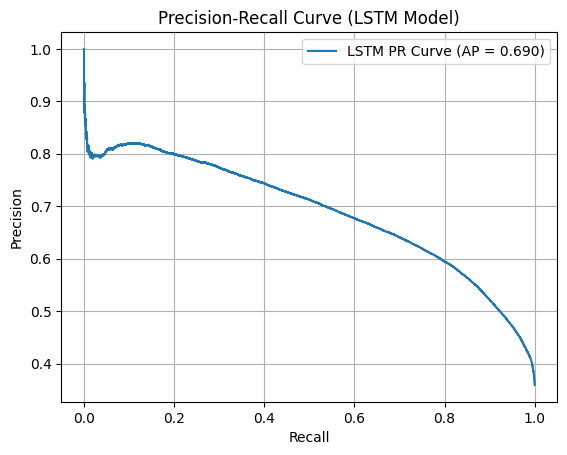

In [15]:
# Get model probabilities for LSTM
y_scores_lstm = lstm_model.predict(X_test_lstm).ravel()

# Calculate precision-recall curve
precision_lstm, recall_lstm, thresholds_lstm = precision_recall_curve(
    y_test_lstm,
    y_scores_lstm
)

# Calculate PR-AUC / Average Precision
ap_lstm = average_precision_score(y_test_lstm, y_scores_lstm)

# Plot
plt.figure()
plt.plot(recall_lstm, precision_lstm, label=f"LSTM PR Curve (AP = {ap_lstm:.3f})")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (LSTM Model)")
plt.legend()
plt.grid()
plt.show()

In [16]:
threshold = 0.40
y_pred_lstm = (y_scores_lstm >= threshold).astype(int)
tn, fp, fn, tp = confusion_matrix(y_test_lstm, y_pred_lstm).ravel()

print(f"True negatives (predicted safe, was safe): {tn:,}")
print(f"False Positive (predicted incident, was safe): {fp:,} false alarms)")
print(f"False Negatives (predicted safe, was an incident) {fn:,} <- This is the danger, must be low")
print(f"True Positives (predicted incident, was an incident): {tp:,}")

True negatives (predicted safe, was safe): 80,119
False Positive (predicted incident, was safe): 25,061 false alarms)
False Negatives (predicted safe, was an incident) 16,210 <- This is the danger, must be low
True Positives (predicted incident, was an incident): 42,743


In [17]:
def optimize_recall_lstm(modelo, X_test_lstm, y_test_lstm, new_threshold=0.40):

    # The LSTM already outputs the probability of class 1 because
    # the final layer uses Dense(1, activation="sigmoid")
    probabilities = modelo.predict(X_test_lstm).ravel()

    # Apply new threshold
    adjusted_predictions = (probabilities >= new_threshold).astype(int)

    print("New Threshold report:")
    print(classification_report(y_test_lstm, adjusted_predictions))

    # Extract confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_lstm, adjusted_predictions).ravel()

    print("Adjusted Confusion matrix")
    print(f"True negatives: {tn:,}")
    print(f"False Positive (false alarms): {fp:,} <- may increase as the cost of higher recall")
    print(f"False Negatives  (danger cases): {fn:,} <- should decrease")
    print(f"True Positives (captured incidents): {tp:,} <- should increase")

In [18]:
predicciones_optimas = optimize_recall_lstm(lstm_model, X_test_lstm, y_test_lstm, new_threshold=0.40)

5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
New Threshold report:
              precision    recall  f1-score   support

           0       0.83      0.76      0.80    105180
           1       0.63      0.73      0.67     58953

    accuracy                           0.75    164133
   macro avg       0.73      0.74      0.73    164133
weighted avg       0.76      0.75      0.75    164133

Adjusted Confusion matrix
True negatives: 80,119
False Positive (false alarms): 25,061 <- may increase as the cost of higher recall
False Negatives  (danger cases): 16,210 <- should decrease
True Positives (captured incidents): 42,743 <- should increase


In [19]:
# Function to tune LSTM hyperparameters and threshold using validation performance
def hyperparameter_tuning_lstm(
    X_train_lstm,
    y_train_lstm,
    X_val_lstm,
    y_val_lstm,
    window_size
):

    # Number of features per timestep
    n_features = X_train_lstm.shape[2]

    # Minimum acceptable precision while maximizing recall
    min_precision = 0.65

    # Hyperparameter search space
    parameters_space = {
        "lstm_units": [32, 64],
        "dense_units": [16, 32],
        "dropout_rate": [0.2, 0.3],
        "batch_size": [64]
    }

    # Generate all possible hyperparameter combinations
    combinations = list(itertools.product(
        parameters_space["lstm_units"],
        parameters_space["dense_units"],
        parameters_space["dropout_rate"],
        parameters_space["batch_size"]
    ))

    # Store results for each trained model
    results = []

    # Start execution timer
    start = time.time()

    # Train one model per hyperparameter combination
    for lstm_units, dense_units, dropout_rate, batch_size in combinations:

        # Print current experiment configuration
        print(
            f"Training: LSTM={lstm_units}, "
            f"Dense={dense_units}, "
            f"Dropout={dropout_rate}, "
            f"Batch={batch_size}"
        )

        # Build LSTM model with current hyperparameters
        model = build_lstm_model(
            window_size=window_size,
            n_features=n_features,
            lstm_units=lstm_units,
            dense_units=dense_units,
            dropout_rate=dropout_rate
        )

        # Stop early if validation loss stops improving
        early_stop = EarlyStopping(
            monitor="val_loss",
            patience=5,
            restore_best_weights=True
        )

        # Train current model
        history_lstm = model.fit(
            X_train_lstm,
            y_train_lstm,
            validation_data=(X_val_lstm, y_val_lstm),
            epochs=20,
            batch_size=batch_size,
            callbacks=[early_stop],
            class_weight=class_weights,
            verbose=0
        )

        # Predict validation probabilities
        probabilities = model.predict(X_val_lstm).ravel()

        # Compute PR-AUC using validation probabilities
        pr_auc = average_precision_score(y_val_lstm, probabilities)

        # Search best threshold by maximizing recall with minimum precision constraint
        best_threshold = 0.0
        best_precision = 0.0
        best_recall = 0.0
        best_f1 = 0.0

        for current_threshold in np.arange(0.10, 0.91, 0.05):
            predictions = (probabilities >= current_threshold).astype(int)

            current_precision = precision_score(
                y_val_lstm,
                predictions,
                zero_division=0
            )

            current_recall = recall_score(
                y_val_lstm,
                predictions,
                zero_division=0
            )

            current_f1 = f1_score(
                y_val_lstm,
                predictions,
                zero_division=0
            )

            if current_precision >= min_precision and current_recall > best_recall:
                best_precision = current_precision
                best_recall = current_recall
                best_f1 = current_f1
                best_threshold = current_threshold

        # Fallback to best F1-score if no threshold reaches the minimum precision
        if best_threshold == 0.0:
            for current_threshold in np.arange(0.10, 0.91, 0.05):
                predictions = (probabilities >= current_threshold).astype(int)

                current_precision = precision_score(
                    y_val_lstm,
                    predictions,
                    zero_division=0
                )

                current_recall = recall_score(
                    y_val_lstm,
                    predictions,
                    zero_division=0
                )

                current_f1 = f1_score(
                    y_val_lstm,
                    predictions,
                    zero_division=0
                )

                if current_f1 > best_f1:
                    best_precision = current_precision
                    best_recall = current_recall
                    best_f1 = current_f1
                    best_threshold = current_threshold

        # Save model configuration and validation performance
        results.append({
            "lstm_units": lstm_units,
            "dense_units": dense_units,
            "dropout_rate": dropout_rate,
            "batch_size": batch_size,
            "epochs_trained": len(history_lstm.history["loss"]),
            "best_threshold": best_threshold,
            "precision": best_precision,
            "recall": best_recall,
            "f1": best_f1,
            "pr_auc": pr_auc,
            "model": model
        })

    # End execution timer
    end = time.time()

    # Sort models by recall first, then PR-AUC, while respecting the precision constraint
    results = sorted(
        results,
        key=lambda x: (x["recall"], x["pr_auc"]),
        reverse=True
    )

    # Select best model based on recall-oriented validation performance
    best_result = results[0]

    # Convert execution time to minutes
    minutos = (end - start) / 60

    # Print tuning summary
    print(f"Tiempo de ejecución: {minutos:.2f} minutos")
    print("LA ARQUITECTURA GANADORA ES:")
    print(f"-> lstm_units: {best_result['lstm_units']}")
    print(f"-> dense_units: {best_result['dense_units']}")
    print(f"-> dropout_rate: {best_result['dropout_rate']}")
    print(f"-> batch_size: {best_result['batch_size']}")
    print(f"-> epochs_trained: {best_result['epochs_trained']}")
    print(f"-> best_threshold: {best_result['best_threshold']:.2f}")
    print(f"\nMejor Score (PR-AUC) en validación: {best_result['pr_auc']:.4f}")
    print(f"Precision en validación: {best_result['precision']:.4f}")
    print(f"Recall en validación: {best_result['recall']:.4f}")
    print(f"F1 en validación: {best_result['f1']:.4f}")

    # Return best model, best threshold, all experiment results, and execution time
    return best_result["model"], best_result["best_threshold"], results, minutos

In [20]:
# Define validation set size as 20% of training data
val_size = int(len(X_train_lstm) * 0.2)

# Use the first 80% for training
X_train_lstm_final = X_train_lstm[:-val_size]
y_train_lstm_final = y_train_lstm[:-val_size]

# Use the last 20% for validation
X_val_lstm = X_train_lstm[-val_size:]
y_val_lstm = y_train_lstm[-val_size:]

# Perform LSTM hyperparameter tuning using validation performance
hyperparameterized_lstm_model, winner_threshold, lstm_tuning_results, execution_minutes = hyperparameter_tuning_lstm(
    X_train_lstm_final,
    y_train_lstm_final,
    X_val_lstm,
    y_val_lstm,
    window_size=window_size
)

Training: LSTM=32, Dense=16, Dropout=0.2, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 5s 996us/step
Training: LSTM=32, Dense=16, Dropout=0.3, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step
Training: LSTM=32, Dense=32, Dropout=0.2, Batch=64


...

5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: LSTM=64, Dense=32, Dropout=0.2, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Training: LSTM=64, Dense=32, Dropout=0.3, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Tiempo de ejecución: 40.00 minutos
LA ARQUITECTURA GANADORA ES:
-> lstm_units: 32
-> dense_units: 16
-> dropout_rate: 0.3
-> batch_size: 64
-> epochs_trained: 6
-> best_threshold: 0.70

Mejor Score (PR-AUC) en validación: 0.2315
Precision en validación: 0.2398
Recall en validación: 0.5935
F1 en validación: 0.3416


In [21]:
def final_model_evaluation_lstm(modelo_campeon, X_test_lstm, y_test_lstm, umbral=0.40):
    print("--- STARTING FINAL EVALUATION LSTM ON FUTURE DATA (2025) ---")

    # La LSTM ya devuelve probabilidades por la capa sigmoid
    probabilidades = modelo_campeon.predict(X_test_lstm).ravel()

    # Apply the selected decision threshold
    predicciones_finales = (probabilidades >= umbral).astype(int)

    print(f"\nPERFORMANCE REPORT (UMBRAL: {umbral * 100:.0f}%)")
    print("=" * 50)
    print(classification_report(y_test_lstm, predicciones_finales))

    # Final confusion matrix
    tn, fp, fn, tp = confusion_matrix(y_test_lstm, predicciones_finales).ravel()

    print("\nFINAL CONFUSION MATRIX:")
    print(f"True negatives (safe hours): {tn:,}")
    print(f"Falsos Positivos (false alarms): {fp:,}")
    print(f"False negatives (missed incidents): {fn:,}")
    print(f"True positives (captured incidents): {tp:,}")

    # Métricas de negocio
    recall_final = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_final = tp / (tp + fp) if (tp + fp) > 0 else 0

    print("\nBUSINESS METRICS (CIVIL PROTECTION):")
    print(f"-> Capture rate (Recall): {recall_final * 100:.1f}% de las inundaciones fueron detectadas.")
    print(f"-> Precision de Alarma: {precision_final * 100:.1f}% de las alertas fueron reales.")

    return {
        "threshold": umbral,
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "recall": recall_final,
        "precision": precision_final
    }

In [ ]:
def save_run_metrics(
    model_name,
    run_id,
    y_true,
    y_proba,
    execution_time_minutes,
    threshold=0.40,
    csv_path="../results/lstm_results.csv",
    extra_info=None
):

    # Create the results directory if it does not exist
    os.makedirs(os.path.dirname(csv_path), exist_ok=True)

    # Convert probabilities into binary predictions using the selected threshold
    y_pred = (y_proba >= threshold).astype(int)

    # Extract confusion matrix values for detailed evaluation
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()

    # Store all evaluation metrics and experiment metadata in a dictionary
    row = {
        "timestamp": datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "model": model_name,
        "run_id": run_id,
        "threshold": threshold,
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "pr_auc": average_precision_score(y_true, y_proba),
        "tn": tn,
        "fp": fp,
        "fn": fn,
        "tp": tp,
        "execution_time_minutes": execution_time_minutes
    }

    # Add optional extra experiment information if provided
    if extra_info is not None:
        row.update(extra_info)

    # Append results to the existing CSV file if it already exists
    if os.path.exists(csv_path):
        results_df = pd.read_csv(csv_path)
        results_df = pd.concat(
            [results_df, pd.DataFrame([row])],
            ignore_index=True
        )

    # Create a new dataframe if this is the first experiment run
    else:
        results_df = pd.DataFrame([row])

    # Save the updated results dataframe to disk
    results_df.to_csv(csv_path, index=False)

    # Return the stored metrics for immediate inspection
    return row

In [23]:
# Evaluate the best tuned LSTM model on the test dataset
lstm_final_results = final_model_evaluation_lstm(
    hyperparameterized_lstm_model,
    X_test_lstm,
    y_test_lstm,
    umbral=winner_threshold
)

--- STARTING FINAL EVALUATION LSTM ON FUTURE DATA (2025) ---
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step

PERFORMANCE REPORT (UMBRAL: 70%)
              precision    recall  f1-score   support

           0       0.74      0.90      0.81    105180
           1       0.71      0.43      0.53     58953

    accuracy                           0.73    164133
   macro avg       0.72      0.66      0.67    164133
weighted avg       0.73      0.73      0.71    164133


FINAL CONFUSION MATRIX:
True negatives (safe hours): 94,886
Falsos Positivos (false alarms): 10,294
False negatives (missed incidents): 33,828
True positives (captured incidents): 25,125

BUSINESS METRICS (CIVIL PROTECTION):
-> Capture rate (Recall): 42.6% de las inundaciones fueron detectadas.
-> Precision de Alarma: 70.9% de las alertas fueron reales.


5130/5130 ━━━━━━━━━━━━━━━━━━━━ 6s 1ms/step


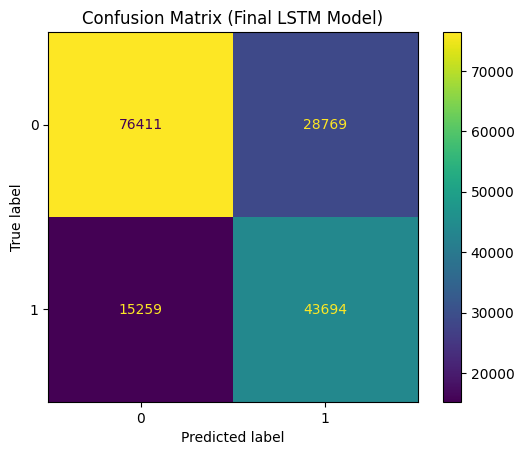

In [24]:
y_pred_final_lstm = (
    hyperparameterized_lstm_model
    .predict(X_test_lstm)
    .ravel() >= 0.40
).astype(int)

ConfusionMatrixDisplay.from_predictions(
    y_test_lstm,
    y_pred_final_lstm
)

plt.title("Confusion Matrix (Final LSTM Model)")
plt.show()

Unlike XGBoost, the LSTM model does not provide direct feature-importance metrics because it learns distributed temporal representations.

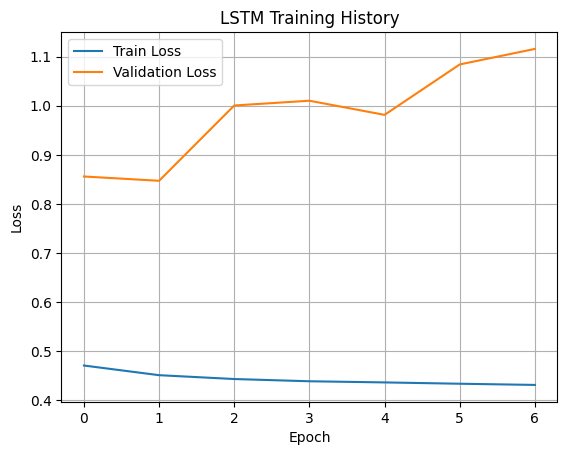

In [25]:
plt.plot(history_lstm.history["loss"], label="Train Loss")
plt.plot(history_lstm.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("LSTM Training History")

plt.legend()
plt.grid()

plt.show()

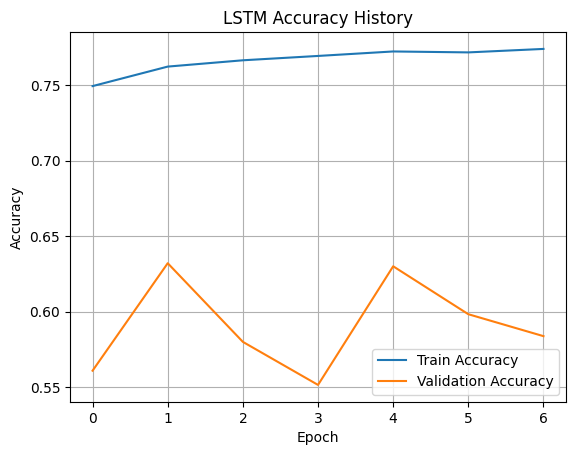

In [26]:
plt.plot(history_lstm.history["accuracy"], label="Train Accuracy")
plt.plot(history_lstm.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("LSTM Accuracy History")

plt.legend()
plt.grid()

plt.show()

In [27]:
TOTAL_RUNS = 5

for run in range(1, TOTAL_RUNS + 1):

    print("=" * 60)
    print(f"STARTING RUN {run}/{TOTAL_RUNS}")
    print("=" * 60)

    # Train and tune the LSTM model
    hyperparameterized_lstm_model, winner_threshold, lstm_tuning_results, execution_minutes = hyperparameter_tuning_lstm(
        X_train_lstm_final,
        y_train_lstm_final,
        X_val_lstm,
        y_val_lstm,
        window_size=window_size
    )

    # Perform final evaluation on the test set
    final_results = final_model_evaluation_lstm(
        hyperparameterized_lstm_model,
        X_test_lstm,
        y_test_lstm,
        umbral=winner_threshold
    )

    # Predict probabilities on the test set
    y_proba = hyperparameterized_lstm_model.predict(X_test_lstm).ravel()

    # Save metrics automatically into CSV
    save_run_metrics(
        model_name="LSTM",
        run_id=run,
        y_true=y_test_lstm,
        y_proba=y_proba,
        execution_time_minutes=execution_minutes,
        threshold=winner_threshold,
        csv_path="../results/lstm_results.csv"
    )

    print(f"RUN {run} COMPLETED")

    # Clear TensorFlow and Python memory between runs
    del hyperparameterized_lstm_model
    del lstm_tuning_results

    tf.keras.backend.clear_session()
    gc.collect()

STARTING RUN 1/5
Training: LSTM=32, Dense=16, Dropout=0.2, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 5s 1ms/step
Training: LSTM=32, Dense=16, Dropout=0.3, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 7s 1ms/step
Training: LSTM=32, Dense=32, Dropout=0.2, Batch=64


...

5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Training: LSTM=64, Dense=32, Dropout=0.2, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Training: LSTM=64, Dense=32, Dropout=0.3, Batch=64


c:\Users\eldeivid\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


5340/5340 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step
Tiempo de ejecución: 49.22 minutos
LA ARQUITECTURA GANADORA ES:
-> lstm_units: 64
-> dense_units: 32
-> dropout_rate: 0.2
-> batch_size: 64
-> epochs_trained: 6
-> best_threshold: 0.65

Mejor Score (PR-AUC) en validación: 0.3568
Precision en validación: 0.3154
Recall en validación: 0.5748
F1 en validación: 0.4073
--- STARTING FINAL EVALUATION LSTM ON FUTURE DATA (2025) ---
5130/5130 ━━━━━━━━━━━━━━━━━━━━ 8s 2ms/step

PERFORMANCE REPORT (UMBRAL: 65%)
              precision    recall  f1-score   support

           0       0.75      0.91      0.82    105180
           1       0.75      0.47      0.58     58953

    accuracy                           0.75    164133
   macro avg       0.75      0.69      0.70    164133
weighted avg       0.75      0.75      0.74    164133


FINAL CONFUSION MATRIX:
True negatives (safe hours): 95,791
Falsos Positivos (false alarms): 9,389
False negatives (missed incidents): 31,270
True positives (captured incidents